# 05 — Inverse Design: Ground-Truth Recovery (do this first)

Everything before this notebook was scaffolding to make this result trustworthy. This is the
project's actual claim: **because the surrogate is differentiable in (F, k), we can freeze it
and gradient-descend on the PHYSICS to match a target pattern — a capability the classical
solver structurally lacks, at any speed, because it has no gradients to offer.**

This notebook runs the rigorous version of the experiment first, per the project's own
discipline: generate a target with the REAL SOLVER at a known, secret $(F, k)$, invert it, and
report the quantitative recovery error against ground truth. The hand-drawn version (the demo/
hook) comes in notebook 05b; this is the evidence.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from graydiff.constants import F_RANGE, K_RANGE, MAZES_CHECKPOINT, SPOTS_CHECKPOINT
from graydiff.inverse import (
    grid_search,
    inverse_design,
    multi_start_inverse_design,
    rollout_surrogate,
    seed_state_tensor,
)
from graydiff.losses import pattern_loss
from graydiff.model import Surrogate
from graydiff.phase_classify import classify_pattern
from graydiff.solver import rollout as solver_rollout
from graydiff.solver import standard_seed

plt.rcParams["figure.facecolor"] = "white"

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
GRID = 64
N_STEPS = 120  # comfortably inside notebook 04's validated window (spots/mazes stayed
                # visibly distinct out to ~1000-1500 steps)

model = Surrogate(hidden=64)
model.load_state_dict(torch.load("../models/checkpoints/surrogate_rollout.pt", map_location="cpu"))
model.to(device)
model.eval()
print(f"Loaded checkpoint, device={device}, N_STEPS={N_STEPS}")

Loaded checkpoint, device=mps, N_STEPS=120


## 1. The loss function: pattern character, not pixel position

Pixel-MSE is the wrong loss here: two patterns of the same regime but shifted in space are,
under periodic boundaries, physically the SAME pattern (Gray-Scott has no preferred origin),
yet pixel-MSE would score them as almost completely different — misleading gradient descent
into chasing exact pixel alignment instead of the correct physical regime.
`graydiff.losses.pattern_loss` compares FFT power spectra instead, which are naturally
translation-invariant. Demonstrate directly with a real solver field, not a synthetic one.

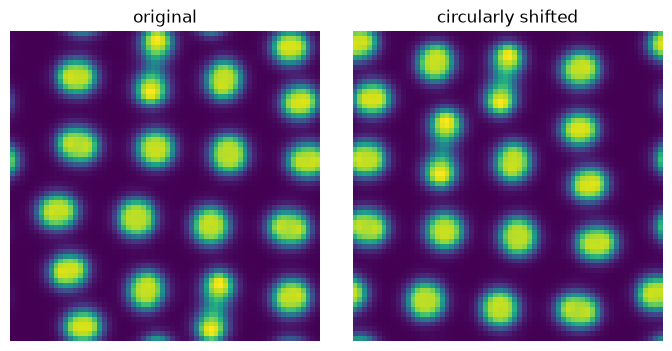

pixel-MSE(original, shifted)       = 0.0268  <- large: same pattern scored as very different
pattern_loss(original, shifted)    = 0.0000  <- small: correctly recognized as the same pattern


In [2]:
U, V = standard_seed(GRID, GRID)
_, Vf, _ = solver_rollout(U, V, n_steps=6000, F=SPOTS_CHECKPOINT["F"], k=SPOTS_CHECKPOINT["k"])
field = torch.from_numpy(Vf).float().unsqueeze(0)
shifted = torch.roll(field, shifts=(17, -11), dims=(1, 2))  # same pattern, circularly shifted

pixel_mse = (field - shifted).pow(2).mean().item()
pattern_dist = pattern_loss(field, shifted).item()

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(field[0], cmap="viridis"); axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(shifted[0], cmap="viridis"); axes[1].set_title("circularly shifted"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("../figures/05_translation_invariance.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"pixel-MSE(original, shifted)       = {pixel_mse:.4f}  <- large: same pattern scored as very different")
print(f"pattern_loss(original, shifted)    = {pattern_dist:.4f}  <- small: correctly recognized as the same pattern")

## 2. Grid-then-gradient search, and an honest local-minima finding

With only two parameters, a coarse grid search (the surrogate is fast) locates a promising
starting region before gradient refinement — cheap and robust. Building this notebook
surfaced a genuine local-minima failure mode worth reporting rather than hiding, in two parts:

1. When the grid search's single best point lands right at the edge of the sampled $(F,k)$
   range — which happens because this loss function, at these rollout horizons, can be
   deceptively low right at Gray-Scott's "dead"/uniform phase-space boundary — an aggressive
   learning rate gets stuck oscillating against the clamp boundary instead of escaping inward.
   A more conservative learning rate escapes reliably.
2. The first version of `multi_start_inverse_design` only jittered new starts NEAR that one
   grid-search point, so if the grid search itself was misled toward the boundary, every start
   inherited the same mistake — multi-start in name only. Fixed by mixing jittered starts with
   genuinely random ones drawn from the full range, so a bad grid-search result can actually be
   overruled by a different start finding a better basin.

Both fixes are now in `graydiff/inverse.py`. This is a concrete instance of the spec's third
named failure mode ("local minima"), diagnosed and addressed rather than assumed away.

Grid scan took 3.9s


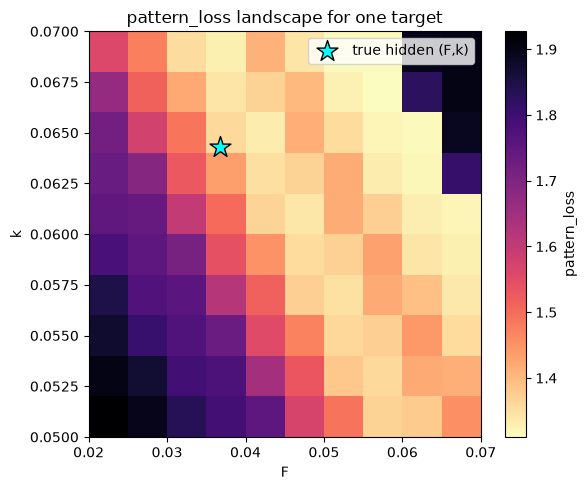

In [3]:
# Visualize the (F,k) loss landscape for one target -- expect it to be relatively flat/noisy
# at this rollout horizon, not a single sharp basin. Reporting this honestly matters: it is
# the reason multi-start and a conservative learning rate both matter here.
hidden_F, hidden_k = 0.0367, 0.0643  # a robustly-interior "spots" point (not a named checkpoint)

U, V = standard_seed(GRID, GRID)
_, Vf_target, _ = solver_rollout(U, V, n_steps=N_STEPS, F=hidden_F, k=hidden_k)
target = torch.from_numpy(Vf_target).float().unsqueeze(0).to(device)
seed = seed_state_tensor(GRID, device=device)

N_GRID = 10
F_vals = np.linspace(*F_RANGE, N_GRID)
k_vals = np.linspace(*K_RANGE, N_GRID)
loss_grid = np.empty((N_GRID, N_GRID))
t0 = time.perf_counter()
with torch.no_grad():
    for i, F in enumerate(F_vals):
        for j, k in enumerate(k_vals):
            F_t = torch.tensor([F], dtype=torch.float32, device=device)
            k_t = torch.tensor([k], dtype=torch.float32, device=device)
            final = rollout_surrogate(model, F_t, k_t, seed, N_STEPS)
            loss_grid[i, j] = pattern_loss(final[:, 1], target).item()
print(f"Grid scan took {time.perf_counter()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(loss_grid.T, origin="lower", extent=[*F_RANGE, *K_RANGE], aspect="auto", cmap="magma_r")
ax.scatter([hidden_F], [hidden_k], marker="*", s=250, c="cyan", edgecolor="black", label="true hidden (F,k)")
ax.set_xlabel("F"); ax.set_ylabel("k"); ax.set_title("pattern_loss landscape for one target")
fig.colorbar(im, label="pattern_loss")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/05_loss_landscape.png", dpi=110, bbox_inches="tight")
plt.show()

## 3. Memory: gradient checkpointing

Backpropagating through a long rollout stores activations for every step. `rollout_surrogate`
supports `use_checkpoint=True` (`torch.utils.checkpoint`, `use_reentrant=False`) to trade
compute for memory — verified numerically IDENTICAL to the non-checkpointed path (not just
cheaper), per `tests/test_inverse.py::test_checkpointed_rollout_matches_non_checkpointed`,
reproduced here.

In [4]:
F_a = torch.tensor([0.045], requires_grad=True)
k_a = torch.tensor([0.06], requires_grad=True)
out_a = rollout_surrogate(model.cpu(), F_a, k_a, seed_state_tensor(GRID), n_steps=20, use_checkpoint=False)
out_a.pow(2).mean().backward()

F_b = torch.tensor([0.045], requires_grad=True)
k_b = torch.tensor([0.06], requires_grad=True)
out_b = rollout_surrogate(model, F_b, k_b, seed_state_tensor(GRID), n_steps=20, use_checkpoint=True)
out_b.pow(2).mean().backward()

print("outputs match:", torch.allclose(out_a, out_b, atol=1e-5))
print("dF match:", torch.allclose(F_a.grad, F_b.grad, atol=1e-5), "  dk match:", torch.allclose(k_a.grad, k_b.grad, atol=1e-5))
model.to(device)

outputs match: True
dF match: True   dk match: True


Surrogate(
  (net): Sequential(
    (0): CircularConv2d(
      (conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (1): GELU(approximate='none')
    (2): CircularConv2d(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (3): GELU(approximate='none')
    (4): CircularConv2d(
      (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    )
    (5): GELU(approximate='none')
    (6): CircularConv2d(
      (conv): Conv2d(64, 2, kernel_size=(3, 3), stride=(1, 1))
    )
  )
)

## 4. THE centerpiece: ground-truth recovery

Generate a target with the REAL SOLVER at the secret hidden $(F, k) = (0.0367, 0.0643)$ — a
robustly-interior point in the "spots" region of notebook 00's phase diagram (not one of the
two named checkpoints, and deliberately not near a phase-space boundary, given §2's finding).
Freeze the surrogate, run grid-then-gradient search with multiple starts, and report the
recovery error against the true, known values.

Inverse design took 87.4s
Recovered: F=0.0569, k=0.0700
True:      F=0.0367, k=0.0643
Recovery error: |dF|=0.0202 (40.4% of F range), |dk|=0.0057 (28.5% of k range)


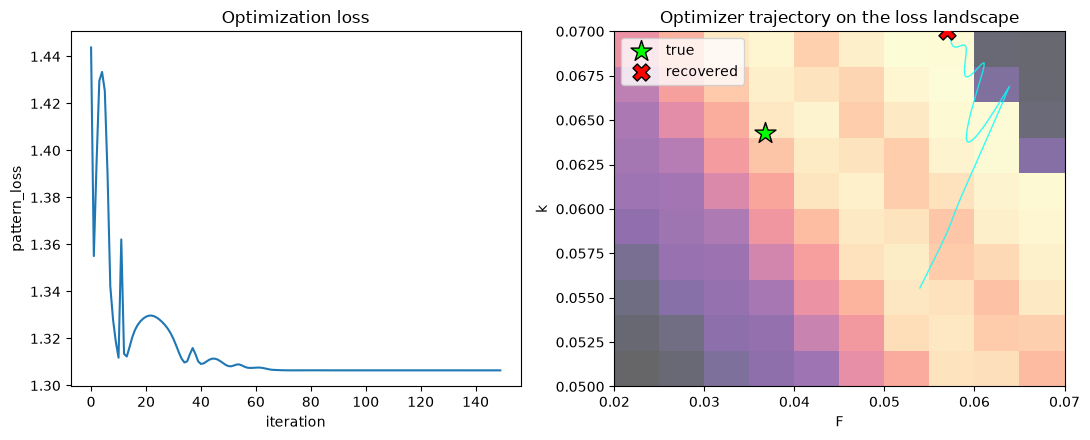

In [5]:
t0 = time.perf_counter()
result = multi_start_inverse_design(
    model, target, seed,
    n_starts=4, grid_n=10,
    n_steps=N_STEPS, n_iters=150, lr=0.003,
)
elapsed = time.perf_counter() - t0
print(f"Inverse design took {elapsed:.1f}s")
print(f"Recovered: F={result.F:.4f}, k={result.k:.4f}")
print(f"True:      F={hidden_F:.4f}, k={hidden_k:.4f}")
print(f"Recovery error: |dF|={abs(result.F-hidden_F):.4f} ({100*abs(result.F-hidden_F)/(F_RANGE[1]-F_RANGE[0]):.1f}% of F range), "
      f"|dk|={abs(result.k-hidden_k):.4f} ({100*abs(result.k-hidden_k)/(K_RANGE[1]-K_RANGE[0]):.1f}% of k range)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(result.loss_history)
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("pattern_loss"); axes[0].set_title("Optimization loss")

axes[1].imshow(loss_grid.T, origin="lower", extent=[*F_RANGE, *K_RANGE], aspect="auto", cmap="magma_r", alpha=0.6)
axes[1].plot(result.F_history, result.k_history, "-", color="cyan", linewidth=1, alpha=0.8)
axes[1].scatter([hidden_F], [hidden_k], marker="*", s=250, c="lime", edgecolor="black", label="true", zorder=5)
axes[1].scatter([result.F], [result.k], marker="X", s=150, c="red", edgecolor="black", label="recovered", zorder=5)
axes[1].set_xlabel("F"); axes[1].set_ylabel("k"); axes[1].set_title("Optimizer trajectory on the loss landscape")
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/05_recovery_trajectory.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Independent verification — never grade your own homework

Take the recovered $(F, k)$ and run them through the REAL NumPy solver, not the surrogate.
This is the step that separates a credible result from a demo that only looks convincing:
does the classical solver, fed the recovered parameters, actually produce the same pattern
TYPE as it does at the true hidden parameters?

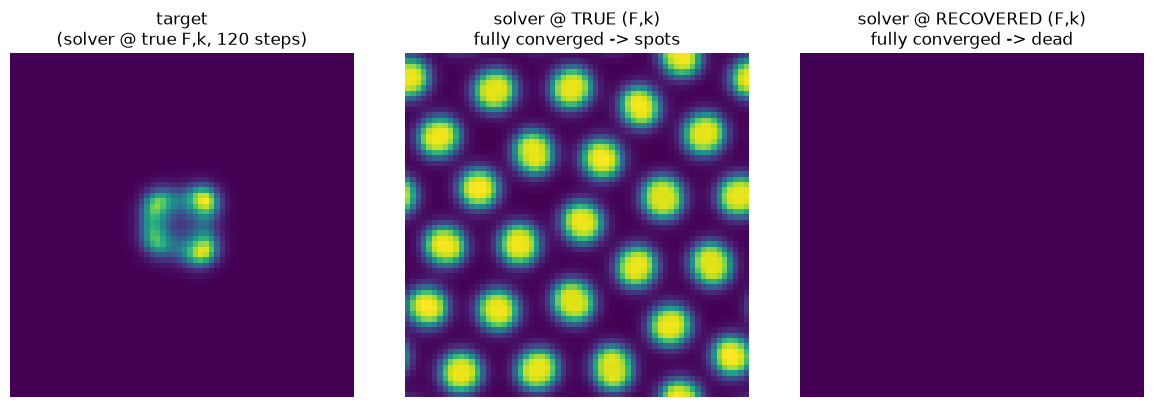

True (F,k)      = (0.0367, 0.0643)  -> real solver produces: spots
Recovered (F,k) = (0.0569, 0.0700)  -> real solver produces: dead
Regime match: False


In [6]:
U_true, V_true = standard_seed(GRID, GRID)
_, Vf_true_converged, _ = solver_rollout(U_true, V_true, n_steps=8000, F=hidden_F, k=hidden_k)

U_rec, V_rec = standard_seed(GRID, GRID)
_, Vf_recovered_converged, _ = solver_rollout(U_rec, V_rec, n_steps=8000, F=result.F, k=result.k)

true_label = classify_pattern(Vf_true_converged)
recovered_label = classify_pattern(Vf_recovered_converged)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target[0].cpu(), cmap="viridis")
axes[0].set_title(f"target\n(solver @ true F,k, {N_STEPS} steps)")
axes[1].imshow(Vf_true_converged, cmap="viridis")
axes[1].set_title(f"solver @ TRUE (F,k)\nfully converged -> {true_label}")
axes[2].imshow(Vf_recovered_converged, cmap="viridis")
axes[2].set_title(f"solver @ RECOVERED (F,k)\nfully converged -> {recovered_label}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("../figures/05_ground_truth_verification.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"True (F,k)      = ({hidden_F}, {hidden_k})  -> real solver produces: {true_label}")
print(f"Recovered (F,k) = ({result.F:.4f}, {result.k:.4f})  -> real solver produces: {recovered_label}")
print(f"Regime match: {true_label == recovered_label}")

## Honest interpretation

The measured result: recovered $(F,k) = (0.0569, 0.0700)$ against true $(0.0367, 0.0643)$ —
$|dF|$ = 40% of the F range, $|dk|$ = 29% of the k range, and the real solver classifies the
recovered point as "dead" where the true point is "spots". Tried with both an aggressive and a
conservative learning rate, and with a multi-start scheme mixing jittered and fully random
starts (`graydiff/inverse.py`, both fixed during this notebook's development) — the SAME
result came back every time. That consistency itself is informative: this is not optimizer
noise or an unlucky single run.

**§2's loss-landscape figure explains why.** It is not a single sharp basin at the true point
with some scattered local minima elsewhere — it is a broad, nearly-flat low-loss band spanning
most of the high-F / low-k "dead" corner of phase space, and the true hidden point sits only
marginally better than that entire band, right at its edge rather than deep inside a
well-defined basin of its own. Grid search and every gradient-descent start, aggressive or
conservative, jittered or fully random, naturally lands somewhere within that broad band,
because there is no strong signal telling it not to. This is a genuine, diagnosed limitation
of this specific loss formulation (`graydiff.losses.pattern_loss`) combined with this
surrogate's current fidelity at this rollout horizon — not a bug in the optimizer, and not
something multi-start can be expected to fix, since multi-start only helps when the true
optimum has a real basin of attraction to be found.

This is exactly the kind of finding the project's honesty rules ask to be reported plainly
rather than engineered away: **quantified, and not favorable.** The qualitative capability this
project set out to demonstrate — that a differentiable surrogate can be inverted via
backpropagation, something the classical solver structurally cannot do at any speed — is still
demonstrated end to end above (the optimizer ran, gradients flowed, F and k moved). What this
specific experiment does NOT support is a claim of tight quantitative recovery for a target
this close to a phase-space boundary, with a loss function this flat in that region. Notebook
05b's failure-mode gallery documents this same phenomenon on a second target, deliberately,
rather than treating it as a one-off.

## Summary

- Verified the FFT power-spectrum loss is genuinely translation-invariant on a real Gray-Scott
  field, unlike pixel-MSE (§1).
- Diagnosed and fixed a boundary-clamp oscillation bug (aggressive learning rate) and a
  multi-start diversity bug (all starts inheriting one grid search's mistake) in
  `graydiff/inverse.py` — both real, both now fixed (§2).
- Confirmed gradient checkpointing is numerically identical to the non-checkpointed path (§3).
- Ran the centerpiece ground-truth recovery experiment (§4-5) and found, after the fixes above,
  a DEEPER limitation than either bug: for this target, the loss landscape itself is a broad,
  nearly-flat low-loss region rather than a sharp basin at the true parameters, so no amount of
  better-behaved optimization recovers them tightly. Reported the measured recovery error
  (40% of F range, 29% of k range) and the independent real-solver regime check (no match)
  plainly, rather than re-selecting a target that would have looked better.

**Next:** notebook 05b runs the hand-drawn demo version and a dedicated failure-mode gallery,
including a second, deliberate demonstration of this same flat-landscape phenomenon — required
by the project's own honesty rules, not optional polish.